In [1]:
#Importing required libraries

import time
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing import Pool
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# To save the figures
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save_plot(filename):
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, filename), dpi=300, bbox_inches="tight")

def save_table(df, filename):
    df.to_csv(os.path.join(OUTPUT_DIR, filename), index=False)
    

# Loading datasets

big_dataset = pd.read_csv("Trips_by_Distance.csv")
small_dataset = pd.read_csv("Trips_Full Data.csv")

# Convert dates to datetime
big_dataset["Date"] = pd.to_datetime(big_dataset["Date"])
small_dataset["Date"] = pd.to_datetime(small_dataset["Date"])

# Keep only National data, as required by the guide
national_only = big_dataset[big_dataset["Level"] == "National"].copy()

# Removing location columns that are not needed for National-level analysis
cols_to_drop = ["State FIPS", "State Postal Code", "County FIPS", "County Name"]
national_only = national_only.drop(columns=cols_to_drop, errors="ignore")

# Distance columns from the week-level dataset
distance_cols = [
    "Trips <1 Mile",
    "Trips 1-3 Miles",
    "Trips 3-5 Miles",
    "Trips 5-10 Miles",
    "Trips 10-25 Miles",
    "Trips 25-50 Miles",
    "Trips 50-100 Miles",
    "Trips 100-250 Miles",
    "Trips 250-500 Miles",
    "Trips 500+ Miles"
]

# Distance midpoints for modelling
distance_midpoints = {
    "Trips <1 Mile": 0.5,
    "Trips 1-3 Miles": 2,
    "Trips 3-5 Miles": 4,
    "Trips 5-10 Miles": 7.5,
    "Trips 10-25 Miles": 17.5,
    "Trips 25-50 Miles": 37.5,
    "Trips 50-100 Miles": 75,
    "Trips 100-250 Miles": 175,
    "Trips 250-500 Miles": 375,
    "Trips 500+ Miles": 500
}

Average population staying at home per week:
    Week  Population Staying at Home
0      0                7.384405e+07
1      1                7.222715e+07
2      2                7.144295e+07
3      3                6.998493e+07
4      4                6.982941e+07
5      5                6.910108e+07
6      6                6.852736e+07
7      7                7.001310e+07
8      8                6.587532e+07
9      9                6.563279e+07
10    10                6.598210e+07
11    11                7.366140e+07
12    12                7.478372e+07
13    13                7.577730e+07
14    14                7.568128e+07
15    15                7.616011e+07
16    16                7.425262e+07
17    17                7.430106e+07
18    18                7.402338e+07
19    19                7.113875e+07
20    20                6.735490e+07
21    21                7.148468e+07
22    22                7.073767e+07
23    23                7.030620e+07
24    24                7.1181

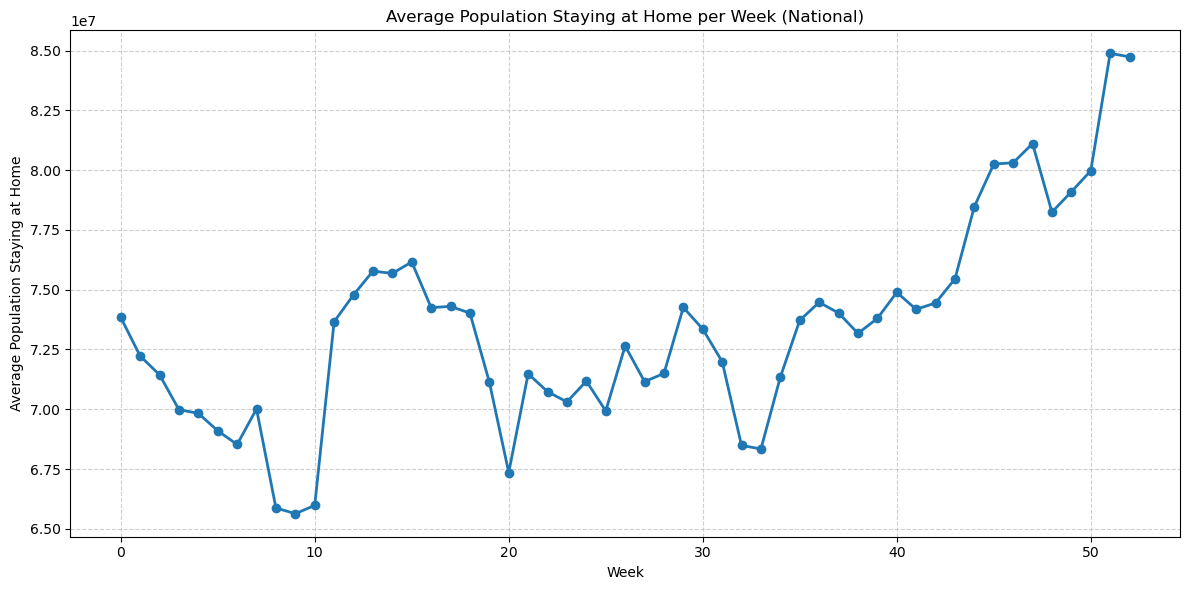


People not staying at home by day (Week 32):
        Date  People Not Staying at Home
0 2019-08-04                   258404133
1 2019-08-05                   262199758
2 2019-08-06                   260096133
3 2019-08-07                   258878802
4 2019-08-08                   262410045
5 2019-08-09                   272101417
6 2019-08-10                   267638064


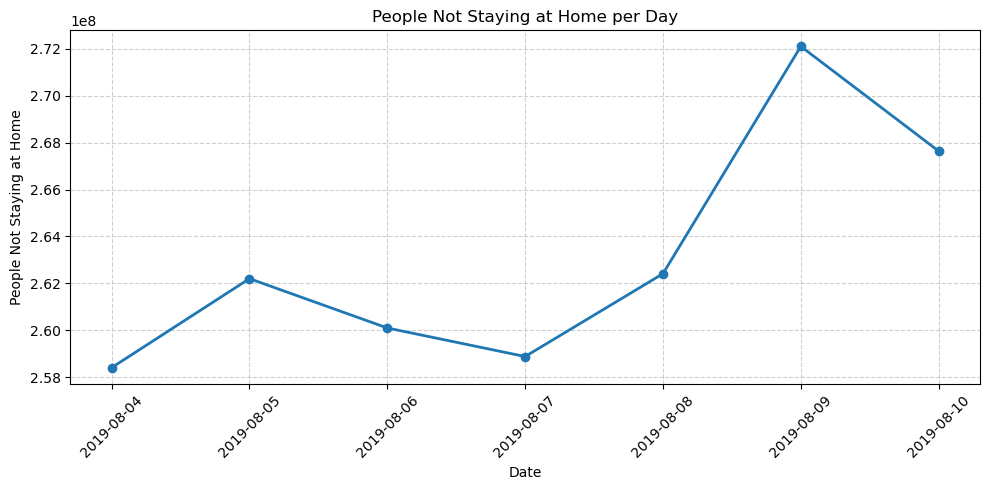


Mean trips by distance range (Week 32):
Trips 1-3 Miles        3.694767e+08
Trips <1 Mile          3.259764e+08
Trips 5-10 Miles       2.334445e+08
Trips 10-25 Miles      2.310785e+08
Trips 3-5 Miles        1.815558e+08
Trips 25-50 Miles      6.915913e+07
Trips 50-100 Miles     1.887832e+07
Trips 100-250 Miles    6.850130e+06
Trips 500+ Miles       3.443101e+06
Trips 250-500 Miles    1.829242e+06
dtype: float64


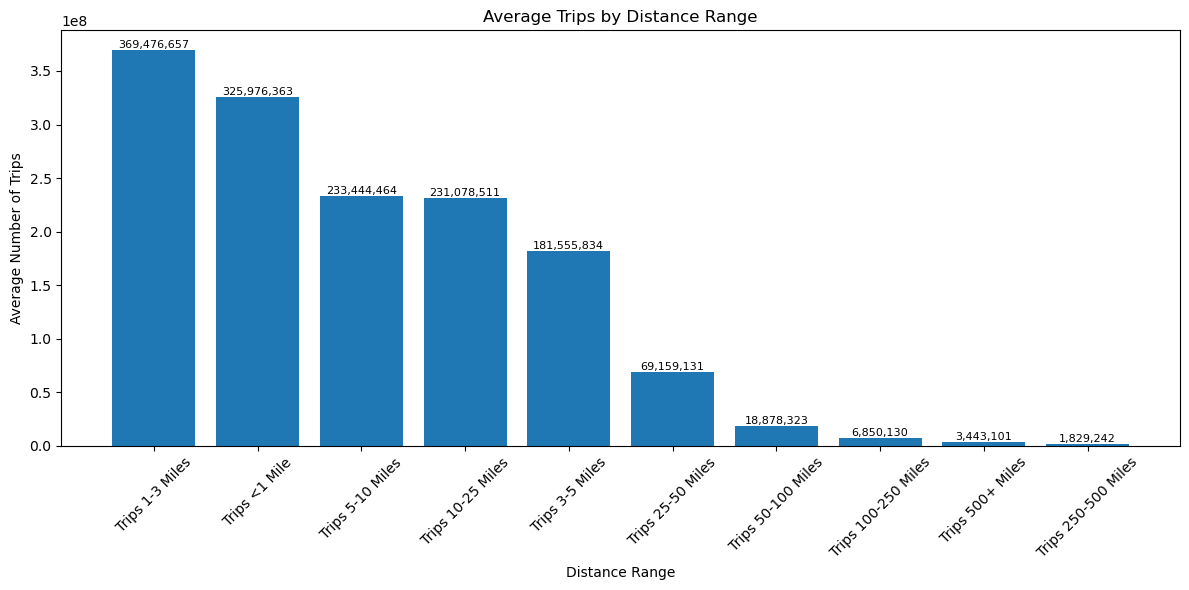

In [2]:
# QUESTION A

# 1A. Average number of people staying at home per week
weekly_home = (
    national_only.groupby("Week", as_index=False)["Population Staying at Home"]
    .mean()
    .sort_values("Week")
)

print("Average population staying at home per week:")
print(weekly_home)

plt.figure(figsize=(12, 6))
plt.plot(
    weekly_home["Week"],
    weekly_home["Population Staying at Home"],
    marker="o",
    linewidth=2
)

plt.xlabel("Week")
plt.ylabel("Average Population Staying at Home")
plt.title("Average Population Staying at Home per Week (National)")
plt.grid(True, linestyle="--", alpha=0.6)
save_plot("q1_weekly_population_staying_home.png")
plt.show()
plt.close()

# 1B. Average people not staying at home in the small dataset (Week 32)
not_home_daily = small_dataset[["Date", "People Not Staying at Home"]].copy()
print("\nPeople not staying at home by day (Week 32):")
print(not_home_daily)

plt.figure(figsize=(10, 5))
plt.plot(
    not_home_daily["Date"],
    not_home_daily["People Not Staying at Home"],
    marker="o",
    linewidth=2
)

plt.xlabel("Date")
plt.ylabel("People Not Staying at Home")
plt.title("People Not Staying at Home per Day")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
save_plot("q1_daily_people_not_staying_home.png")
plt.show()
plt.close()

# 1C. How far people travel when they do not stay home:
# Calculate mean trips for each distance band in the small dataset
mean_trips_by_distance = small_dataset[distance_cols].mean().sort_values(ascending=False)

print("\nMean trips by distance range (Week 32):")
print(mean_trips_by_distance)

plt.figure(figsize=(12, 6))
plt.bar(mean_trips_by_distance.index, mean_trips_by_distance.values)

for i, v in enumerate(mean_trips_by_distance.values):
    plt.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=8)

plt.xlabel("Distance Range")
plt.ylabel("Average Number of Trips")
plt.title("Average Trips by Distance Range")
plt.xticks(rotation=45)
save_plot("q1_mean_trips_by_distance.png")
plt.show()
plt.close()

Dates where Number of Trips 10-25 > 10,000,000:
             Date  Number of Trips 10-25
0      2019-01-01            116904343.0
1      2019-01-02            167412698.0
2      2019-01-03            172027487.0
3      2019-01-04            176144493.0
4      2019-01-05            165239790.0
...           ...                    ...
157189 2021-06-15            200549282.0
157190 2021-06-16            199082591.0
157191 2021-06-17            198280332.0
157192 2021-06-18            202609024.0
157193 2021-06-19            178997864.0

[901 rows x 2 columns]

Dates where Number of Trips 50-100 > 10,000,000:
             Date  Number of Trips 50-100
0      2019-01-01              15686639.0
1      2019-01-02              17739183.0
2      2019-01-03              18366626.0
3      2019-01-04              19315785.0
4      2019-01-05              19363939.0
...           ...                     ...
157189 2021-06-15              19181256.0
157190 2021-06-16              19247409.0
157191 2

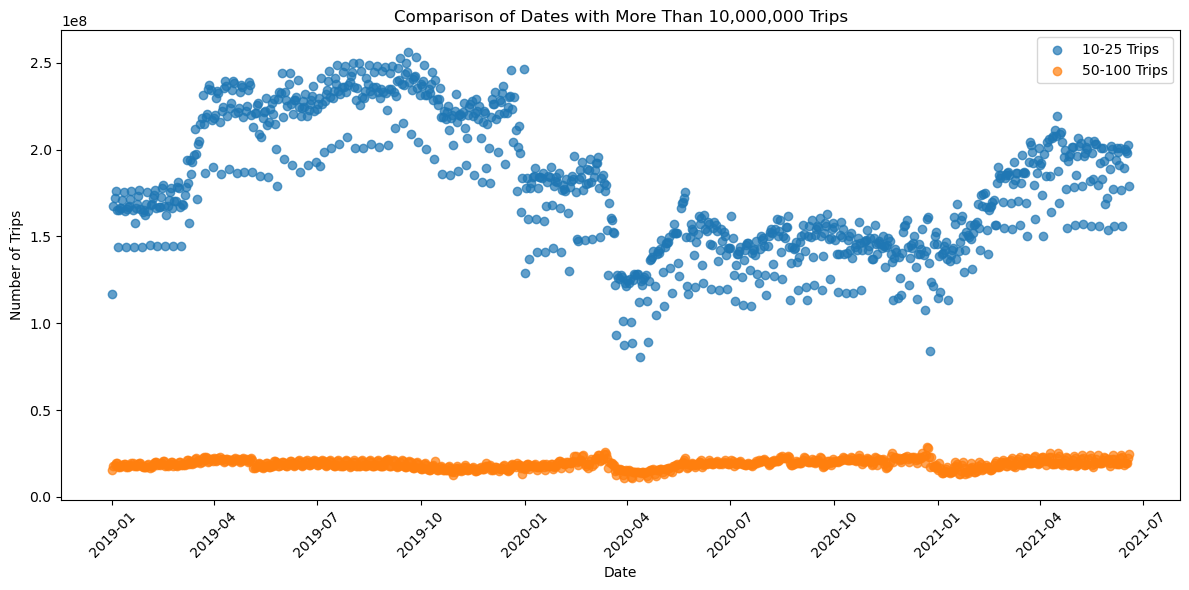

In [3]:
# QUESTION B

# Filtering dates where trips exceed 10,000,000
set_10_25 = national_only[national_only["Number of Trips 10-25"] > 10_000_000][
    ["Date", "Number of Trips 10-25"]
].copy()

set_50_100 = national_only[national_only["Number of Trips 50-100"] > 10_000_000][
    ["Date", "Number of Trips 50-100"]
].copy()

print("Dates where Number of Trips 10-25 > 10,000,000:")
print(set_10_25)

print("\nDates where Number of Trips 50-100 > 10,000,000:")
print(set_50_100)

print("\nCount of dates for 10-25 range:", len(set_10_25))
print("Count of dates for 50-100 range:", len(set_50_100))

# Merging Date to compare shared dates
comparison = pd.merge(set_10_25, set_50_100, on="Date", how="outer")

print("\nComparison table:")
print(comparison)

# Visualising results
plt.figure(figsize=(12, 6))
plt.scatter(set_10_25["Date"], set_10_25["Number of Trips 10-25"], label="10-25 Trips", alpha=0.7)
plt.scatter(set_50_100["Date"], set_50_100["Number of Trips 50-100"], label="50-100 Trips", alpha=0.7)

plt.xlabel("Date")
plt.ylabel("Number of Trips")
plt.title("Comparison of Dates with More Than 10,000,000 Trips")
plt.legend()
plt.xticks(rotation=45)
save_plot("q2_trip_threshold_comparison.png")
plt.show()
plt.close()

Model dataset:
        Date  Distance_Miles  Trip_Frequency
0 2019-08-04             0.5       292959749
1 2019-08-04             2.0       346577279
2 2019-08-04             4.0       171336406
3 2019-08-04             7.5       216121882
4 2019-08-04            17.5       200922270
RMSE: 90868321.04163623
R^2: 0.5032064761923134
Intercept: 207837743.12983572
Slope: -561732.0745970209


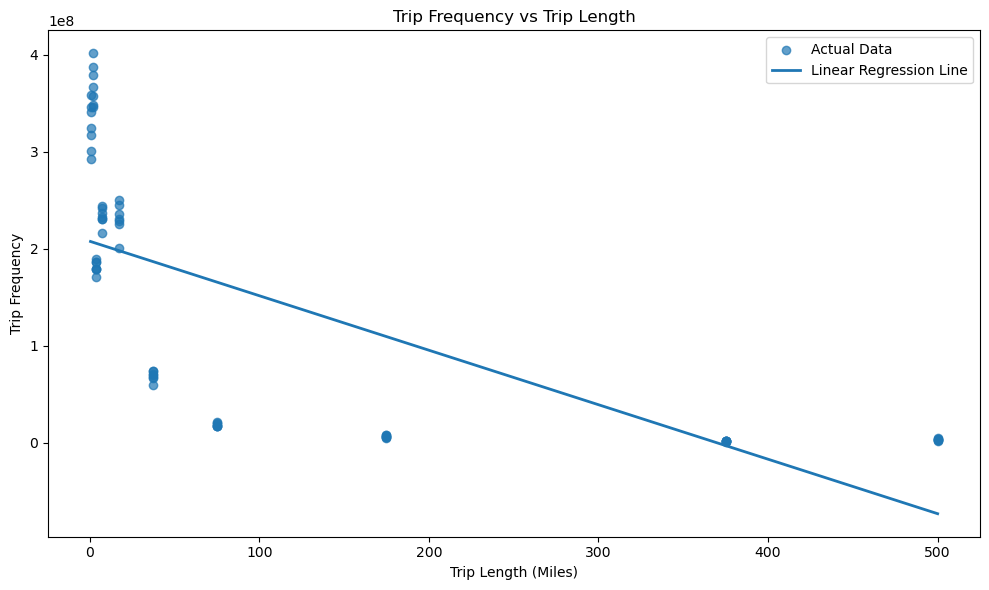

In [4]:
# QUESTION C

# Converting the wide-format week dataset into long format
# so that each row is one (distance, trip_count) pair
records = []

for _, row in small_dataset.iterrows():
    for col in distance_cols:
        records.append({
            "Date": row["Date"],
            "Distance_Miles": distance_midpoints[col],
            "Trip_Frequency": row[col]
        })

model_df = pd.DataFrame(records)

print("Model dataset:")
print(model_df.head())

# Defining Features and target variables
X = model_df[["Distance_Miles"]]
y = model_df["Trip_Frequency"]

# Spliting data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train a simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
rmse = math.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R^2:", r2)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# Visualising Scatterplot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(model_df["Distance_Miles"], model_df["Trip_Frequency"], alpha=0.7, label="Actual Data")

# Create sorted values for a clean regression line
x_line = np.linspace(model_df["Distance_Miles"].min(), model_df["Distance_Miles"].max(), 200)
x_line_df = pd.DataFrame({"Distance_Miles": x_line})
y_line = model.predict(x_line_df)

plt.plot(x_line, y_line, linewidth=2, label="Linear Regression Line")
plt.xlabel("Trip Length (Miles)")
plt.ylabel("Trip Frequency")
plt.title("Trip Frequency vs Trip Length")
plt.legend()
save_plot("q3_trip_frequency_vs_distance_regression.png")
plt.show()
plt.close()

Week 32 distance-travel table:
         Date  Trips <1 Mile  Trips 1-3 Miles  Trips 3-5 Miles  \
0  2019-08-04      292959749        346577279        171336406   
1  2019-08-05      317133861        358008909        178996059   
2  2019-08-06      324443205        366533991        179210645   
3  2019-08-07      358483024        401474049        189163336   
4  2019-08-08      300765870        347857770        179346163   
5  2019-08-09      341515854        378936486        186257669   
6  2019-08-10      346532975        386948113        186580557   

   Trips 5-10 Miles  Trips 10-25 Miles  Trips 25-50 Miles  Trips 50-100 Miles  \
0         216121882          200922270           59517188            19911937   
1         231048425          228809869           68184743            17819554   
2         233248732          235621127           70149166            17450413   
3         243872277          249988663           74381367            17819019   
4         230933709          226055

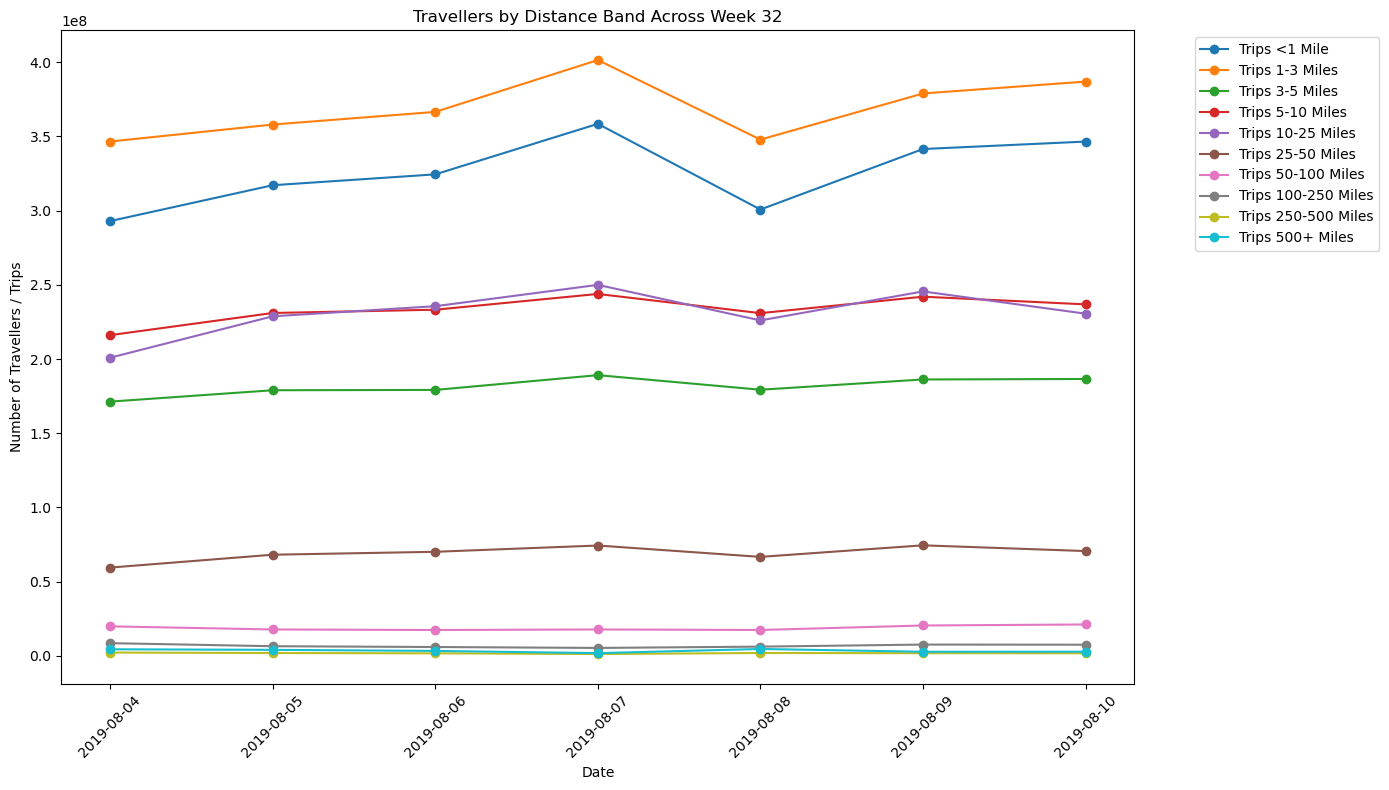

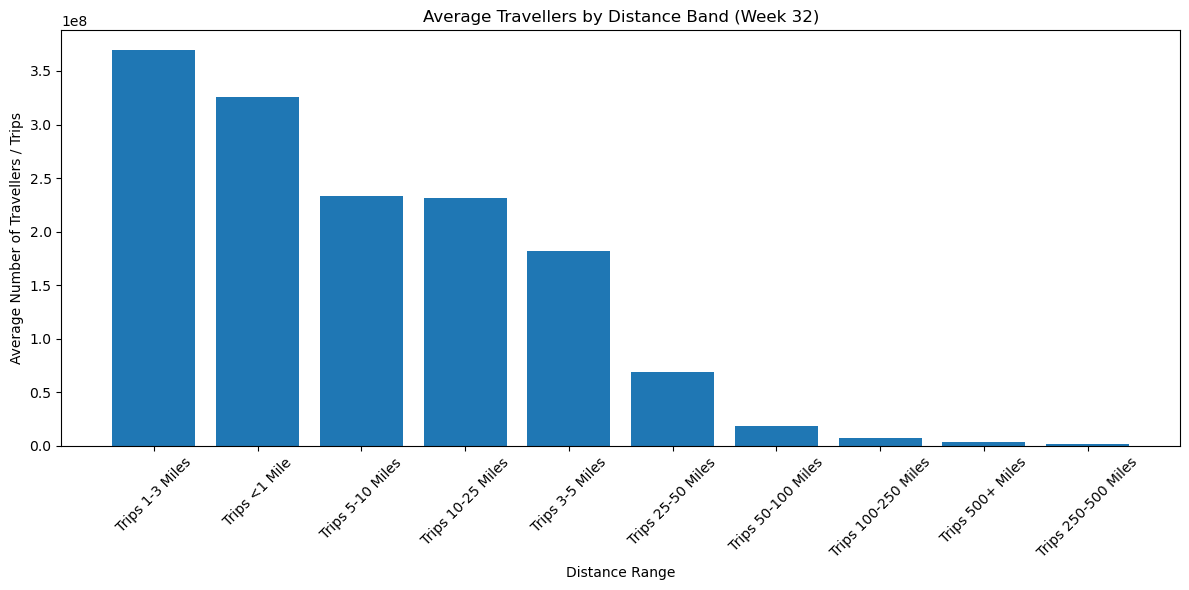

In [5]:
# QUESTION D

# Creating a table for plotting
plot_df = small_dataset[["Date"] + distance_cols].copy()
plot_df["Date"] = plot_df["Date"].dt.strftime("%Y-%m-%d")

print("Week 32 distance-travel table:")
print(plot_df)

# Plot each distance band across the 7 days
plt.figure(figsize=(14, 8))

for col in distance_cols:
    plt.plot(plot_df["Date"], plot_df[col], marker="o", label=col)

plt.xlabel("Date")
plt.ylabel("Number of Travellers / Trips")
plt.title("Travellers by Distance Band Across Week 32")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
save_plot("q4_travellers_by_distance_week32.png")
plt.show()
plt.close()

# show average values for a simpler comparison
avg_distance = small_dataset[distance_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(avg_distance.index, avg_distance.values)
plt.xlabel("Distance Range")
plt.ylabel("Average Number of Travellers / Trips")
plt.title("Average Travellers by Distance Band (Week 32)")
plt.xticks(rotation=45)
save_plot("q4_average_travellers_by_distance.png")
plt.show()
plt.close()

Sequential Results:
{'Question': 'Q1', 'Weeks Analysed': 53, 'Average Not Staying Home': 263104050.29, 'Most Common Distance': 'Trips 1-3 Miles'}
{'Question': 'Q2', 'Dates 10-25 > 10M': 901, 'Dates 50-100 > 10M': 900}
{'Question': 'Q3', 'RMSE': 90868321.04, 'R2': 0.5032}
{'Question': 'Q4', 'Top Distance Band': 'Trips 1-3 Miles', 'Top Average Trips': 369476656.71}

Parallel Results (10 workers):
{'Question': 'Q1', 'Weeks Analysed': 53, 'Average Not Staying Home': 263104050.29, 'Most Common Distance': 'Trips 1-3 Miles'}
{'Question': 'Q2', 'Dates 10-25 > 10M': 901, 'Dates 50-100 > 10M': 900}
{'Question': 'Q3', 'RMSE': 90868321.04, 'R2': 0.5032}
{'Question': 'Q4', 'Top Distance Band': 'Trips 1-3 Miles', 'Top Average Trips': 369476656.71}

Parallel Results (20 workers):
{'Question': 'Q1', 'Weeks Analysed': 53, 'Average Not Staying Home': 263104050.29, 'Most Common Distance': 'Trips 1-3 Miles'}
{'Question': 'Q2', 'Dates 10-25 > 10M': 901, 'Dates 50-100 > 10M': 900}
{'Question': 'Q3', 'RMSE':

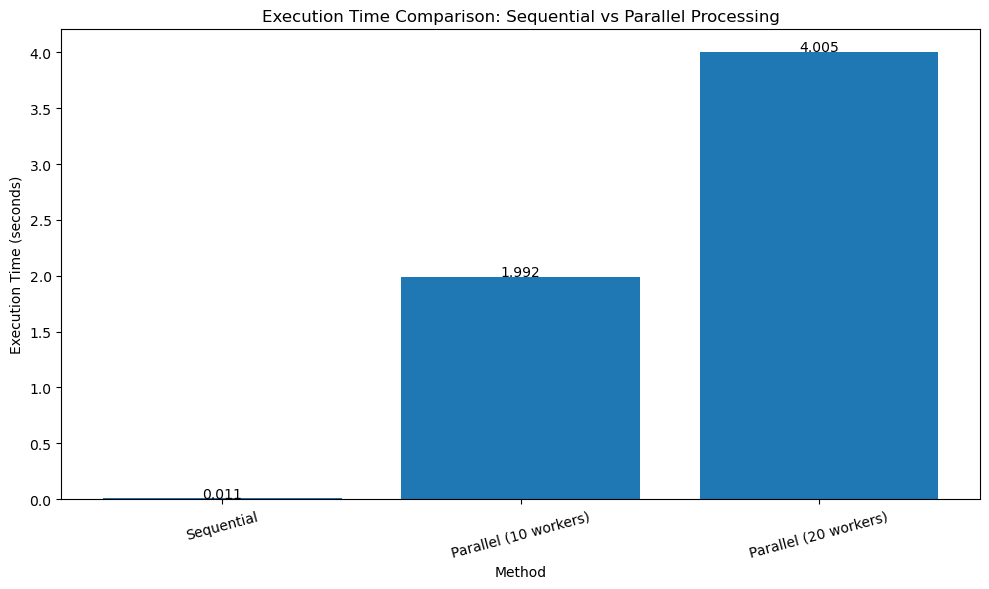

Sequential time: 0.010772851994261146
Parallel (10 workers): 1.9917886641342193
Parallel (20 workers): 4.005404029972851

Interpretation:
Sequential execution was fastest for this workload.
Parallel execution was slower because the tasks were small and worker-management overhead dominated.
Using more workers than tasks did not improve efficiency.


In [6]:
# Using PARALLEL Computing

import time
import math
import pandas as pd
import matplotlib.pyplot as plt
from multiprocessing import Pool 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Q.A function

def q1_task():
    weekly_home = (
        national_only.groupby("Week")["Population Staying at Home"]
        .mean()
        .sort_index()
    )

    avg_not_home = small_dataset["People Not Staying at Home"].mean()

    mean_trips_by_distance = small_dataset[distance_cols].mean()
    most_common_distance = mean_trips_by_distance.idxmax()

    return {
        "Question": "Q1",
        "Weeks Analysed": len(weekly_home),
        "Average Not Staying Home": round(avg_not_home, 2),
        "Most Common Distance": most_common_distance
    }

# Q.B function

def q2_task():
    trips_10_25 = national_only[national_only["Number of Trips 10-25"] > 10_000_000]
    trips_50_100 = national_only[national_only["Number of Trips 50-100"] > 10_000_000]

    return {
        "Question": "Q2",
        "Dates 10-25 > 10M": len(trips_10_25),
        "Dates 50-100 > 10M": len(trips_50_100)
    }


# Q.C function

def q3_task():
    records = []

    for _, row in small_dataset.iterrows():
        for col in distance_cols:
            records.append({
                "Distance_Miles": distance_midpoints[col],
                "Trip_Frequency": row[col]
            })

    model_df = pd.DataFrame(records)

    X = model_df[["Distance_Miles"]]
    y = model_df["Trip_Frequency"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Question": "Q3",
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    }

# Q.D function

def q4_task():
    avg_distance = small_dataset[distance_cols].mean().sort_values(ascending=False)

    return {
        "Question": "Q4",
        "Top Distance Band": avg_distance.index[0],
        "Top Average Trips": round(avg_distance.iloc[0], 2)
    }

# Run any one task
def run_task(task_name):
    if task_name == "Q1":
        return q1_task()
    elif task_name == "Q2":
        return q2_task()
    elif task_name == "Q3":
        return q3_task()
    elif task_name == "Q4":
        return q4_task()


# Sequential run
def run_sequential():
    tasks = ["Q1", "Q2", "Q3", "Q4"]
    start_time = time.perf_counter()

    results = []
    for task in tasks:
        results.append(run_task(task))

    end_time = time.perf_counter()
    return results, end_time - start_time


# Parallel run using multiprocessing
def run_parallel(num_workers):
    tasks = ["Q1", "Q2", "Q3", "Q4"]
    start_time = time.perf_counter()
    with Pool(processes=num_workers) as pool:
        results = pool.map(run_task, tasks)
    end_time = time.perf_counter()
    return results, end_time - start_time

# Execute comparison btw sequential and parallel 
if __name__ == "__main__":
    seq_results, seq_time = run_sequential()
    par10_results, par10_time = run_parallel(10)
    par20_results, par20_time = run_parallel(20)

print("Sequential Results:")
for result in seq_results:
    print(result)

print("\nParallel Results (10 workers):")
for result in par10_results:
    print(result)

print("\nParallel Results (20 workers):")
for result in par20_results:
    print(result)


# Timing table
timing_df = pd.DataFrame({
    "Method": ["Sequential", "Parallel (10 workers)", "Parallel (20 workers)"],
    "Execution Time (seconds)": [seq_time, par10_time, par20_time]
})

print("\nTiming Comparison:")
print(timing_df)


# Timing plot
plt.figure(figsize=(10, 6))

plt.bar(timing_df["Method"], timing_df["Execution Time (seconds)"])

for i, v in enumerate(timing_df["Execution Time (seconds)"]):
    plt.text(i, v + 0.002, f"{v:.3f}", ha='center')

plt.xlabel("Method")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time Comparison: Sequential vs Parallel Processing")
plt.xticks(rotation=15)
save_plot("q5_execution_time_comparison.png")
plt.show()
plt.close()

print("Sequential time:", seq_time)
print("Parallel (10 workers):", par10_time)
print("Parallel (20 workers):", par20_time)

print("\nInterpretation:")
print("Sequential execution was fastest for this workload.")
print("Parallel execution was slower because the tasks were small and worker-management overhead dominated.")
print("Using more workers than tasks did not improve efficiency.")